# Erode masks and generate dataset (kernel size 10, iterations 1)

This notebook creates a versioned dataset with **eroded masks** as the main artifact and also saves segmented preview images.

Outputs:
- `data/PANCREAS_PREPROCESSED_ERODED_K9_I1/masks/`
- `data/PANCREAS_PREPROCESSED_ERODED_K9_I1/segmented/`
- `data/PANCREAS_PREPROCESSED_ERODED_K9_I1/manifest_eroded_k9_i1.csv`

In [1]:
from pathlib import Path
from datetime import datetime
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
INPUT_DIR = Path("../data/PANCREAS_PREPROCESSED")
OUTPUT_DIR = Path("../data/PANCREAS_PREPROCESSED_ERODED_K10_I1")
KERNEL_SIZE = 10
ITERATIONS = 1
SAVE_SEGMENTED_PREVIEWS = True
SEGMENTED_SUFFIX = "segmented_k10_i1"
MASK_SUFFIX = "mask_eroded_k10_i1"
FLAG_THRESHOLD_LOSS_PCT = 30.0

OUTPUT_MASK_DIR = OUTPUT_DIR / "masks"
OUTPUT_SEGMENTED_DIR = OUTPUT_DIR / "segmented"
MANIFEST_PATH = OUTPUT_DIR / "manifest_eroded_k10_i1.csv"

OUTPUT_MASK_DIR.mkdir(parents=True, exist_ok=True)
if SAVE_SEGMENTED_PREVIEWS:
    OUTPUT_SEGMENTED_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_DIR.resolve())
print("Output:", OUTPUT_DIR.resolve())
print("Kernel:", KERNEL_SIZE, "Iterations:", ITERATIONS)
print("Save segmented previews:", SAVE_SEGMENTED_PREVIEWS)

Input: /home/daniduhnev/projects/master-thesis/data/PANCREAS_PREPROCESSED
Output: /home/daniduhnev/projects/master-thesis/data/PANCREAS_PREPROCESSED_ERODED_K10_I1
Kernel: 10 Iterations: 1
Save segmented previews: True


In [2]:
# Build image/mask pairs
image_files = sorted(INPUT_DIR.glob("*_image.png"))
mask_files = sorted(INPUT_DIR.glob("*_mask.png"))

mask_map = {p.name.replace("_mask.png", ""): p for p in mask_files}
pairs = []

for img_path in image_files:
    study_id = img_path.name.replace("_image.png", "")
    mask_path = mask_map.get(study_id)
    if mask_path is not None:
        pairs.append((study_id, img_path, mask_path))

print("Image files:", len(image_files))
print("Mask files:", len(mask_files))
print("Paired studies:", len(pairs))

if len(pairs) == 0:
    raise ValueError("No image/mask pairs found. Check INPUT_DIR.")

Image files: 134
Mask files: 134
Paired studies: 134


In [3]:
# Erode masks and export outputs
kernel = np.ones((KERNEL_SIZE, KERNEL_SIZE), np.uint8)
rows = []

timestamp = datetime.now().isoformat(timespec="seconds")

for study_id, img_path, mask_path in pairs:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if image is None or mask_gray is None:
        continue

    mask_bin = (mask_gray > 0).astype(np.uint8)
    eroded = cv2.erode(mask_bin, kernel, iterations=ITERATIONS)

    orig_pixels = int(mask_bin.sum())
    eroded_pixels = int(eroded.sum())
    lost_pixels = orig_pixels - eroded_pixels
    lost_pct = (lost_pixels / orig_pixels * 100.0) if orig_pixels > 0 else np.nan

    out_mask_name = f"{study_id}_{MASK_SUFFIX}.png"
    out_mask_path = OUTPUT_MASK_DIR / out_mask_name
    cv2.imwrite(str(out_mask_path), (eroded * 255).astype(np.uint8))

    segmented_rel_path = ""
    if SAVE_SEGMENTED_PREVIEWS:
        segmented = cv2.bitwise_and(image, image, mask=(eroded * 255).astype(np.uint8))
        out_seg_name = f"{study_id}_{SEGMENTED_SUFFIX}.png"
        out_seg_path = OUTPUT_SEGMENTED_DIR / out_seg_name
        cv2.imwrite(str(out_seg_path), segmented)
        segmented_rel_path = str(out_seg_path.relative_to(OUTPUT_DIR))

    rows.append(
        {
            "study_id": study_id,
            "source_image": str(img_path.resolve()),
            "source_mask": str(mask_path.resolve()),
            "output_mask_rel": str(out_mask_path.relative_to(OUTPUT_DIR)),
            "output_segmented_rel": segmented_rel_path,
            "kernel_size": KERNEL_SIZE,
            "iterations": ITERATIONS,
            "orig_pixels": orig_pixels,
            "eroded_pixels": eroded_pixels,
            "lost_pixels": lost_pixels,
            "lost_pct": round(float(lost_pct), 6) if not np.isnan(lost_pct) else np.nan,
            "generated_at": timestamp,
        }
    )

manifest_df = pd.DataFrame(rows).sort_values("study_id").reset_index(drop=True)
manifest_df.to_csv(MANIFEST_PATH, index=False)

print("Saved manifest:", MANIFEST_PATH.resolve())
print("Rows:", len(manifest_df))
print("Masks saved to:", OUTPUT_MASK_DIR.resolve())
if SAVE_SEGMENTED_PREVIEWS:
    print("Segmented previews saved to:", OUTPUT_SEGMENTED_DIR.resolve())

Saved manifest: /home/daniduhnev/projects/master-thesis/data/PANCREAS_PREPROCESSED_ERODED_K10_I1/manifest_eroded_k10_i1.csv
Rows: 134
Masks saved to: /home/daniduhnev/projects/master-thesis/data/PANCREAS_PREPROCESSED_ERODED_K10_I1/masks
Segmented previews saved to: /home/daniduhnev/projects/master-thesis/data/PANCREAS_PREPROCESSED_ERODED_K10_I1/segmented


In [4]:
# QA summary
if manifest_df.empty:
    raise ValueError("Manifest is empty. Nothing was exported.")

print("\nLoss summary (lost_pct):")
print(manifest_df["lost_pct"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(3).to_string())

flagged = manifest_df[manifest_df["lost_pct"] > FLAG_THRESHOLD_LOSS_PCT].copy()
print(f"\nFlag threshold: > {FLAG_THRESHOLD_LOSS_PCT}%")
print(f"Flagged studies: {len(flagged)}/{len(manifest_df)}")

if len(flagged) > 0:
    print("\nTop flagged studies:")
    print(
        flagged.sort_values("lost_pct", ascending=False)[
            ["study_id", "orig_pixels", "eroded_pixels", "lost_pixels", "lost_pct"]
        ].head(15).to_string(index=False)
    )

manifest_df.head()


Loss summary (lost_pct):
count    134.000
mean      21.893
std        7.334
min       11.081
50%       20.510
75%       25.000
90%       31.353
95%       36.460
max       56.074

Flag threshold: > 30.0%
Flagged studies: 15/134

Top flagged studies:
study_id  orig_pixels  eroded_pixels  lost_pixels  lost_pct
   28_03         2848           1251         1597 56.074438
   27_01         5964           3267         2697 45.221328
   14_01         5511           3149         2362 42.859735
   33_03         3585           2129         1456 40.613668
   56_03         8421           5120         3301 39.199620
   16_01         5040           3137         1903 37.757937
   08_01        10202           6463         3739 36.649677
   07_02         8078           5141         2937 36.358009
   01_05         7983           5144         2839 35.563072
   55_02         3811           2529         1282 33.639465
   06_03        10325           6895         3430 33.220339
   06_04         9279         

,study_id,source_image,source_mask,output_mask_rel,output_segmented_rel,kernel_size,iterations,orig_pixels,eroded_pixels,lost_pixels,lost_pct,generated_at
0,01_01,/home/daniduhnev/projects/master-thesis/data/P...,/home/daniduhnev/projects/master-thesis/data/P...,masks/01_01_mask_eroded_k10_i1.png,segmented/01_01_segmented_k10_i1.png,10,1,21086,16527,4559,21.620981,2026-03-03T17:45:07
1,01_02,/home/daniduhnev/projects/master-thesis/data/P...,/home/daniduhnev/projects/master-thesis/data/P...,masks/01_02_mask_eroded_k10_i1.png,segmented/01_02_segmented_k10_i1.png,10,1,13998,10308,3690,26.360909,2026-03-03T17:45:07
2,01_03,/home/daniduhnev/projects/master-thesis/data/P...,/home/daniduhnev/projects/master-thesis/data/P...,masks/01_03_mask_eroded_k10_i1.png,segmented/01_03_segmented_k10_i1.png,10,1,16032,12147,3885,24.232784,2026-03-03T17:45:07
3,01_04,/home/daniduhnev/projects/master-thesis/data/P...,/home/daniduhnev/projects/master-thesis/data/P...,masks/01_04_mask_eroded_k10_i1.png,segmented/01_04_segmented_k10_i1.png,10,1,13044,9423,3621,27.759890,2026-03-03T17:45:07
4,01_05,/home/daniduhnev/projects/master-thesis/data/P...,/home/daniduhnev/projects/master-thesis/data/P...,masks/01_05_mask_eroded_k10_i1.png,segmented/01_05_segmented_k10_i1.png,10,1,7983,5144,2839,35.563072,2026-03-03T17:45:07


Sample IDs: ['28_03', '27_01', '14_01', '33_03', '56_03', '16_01']


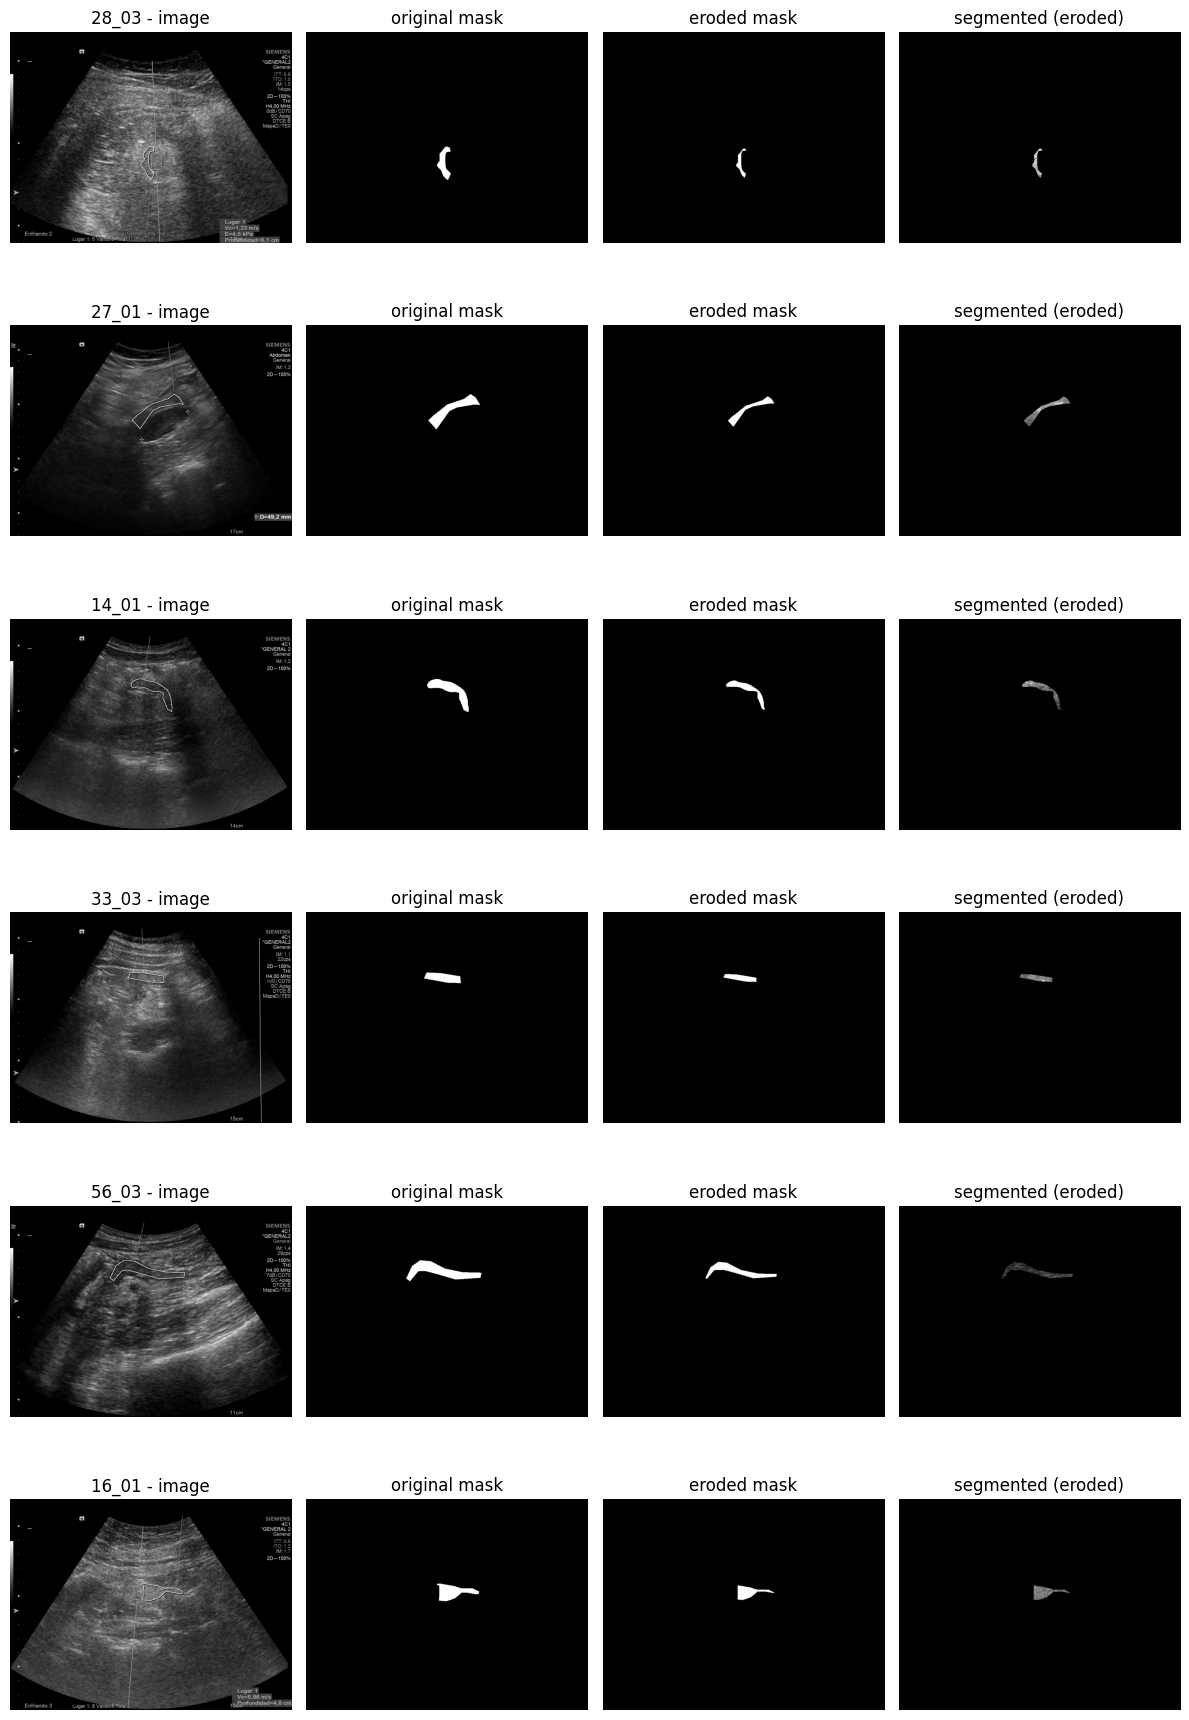

In [5]:
# Visual QA for a few studies
# Priority: flagged studies first, then fill with first rows
sample_ids = flagged.sort_values("lost_pct", ascending=False)["study_id"].head(6).tolist()
if len(sample_ids) < 6:
    extra = [s for s in manifest_df["study_id"].tolist() if s not in sample_ids]
    sample_ids += extra[: 6 - len(sample_ids)]

print("Sample IDs:", sample_ids)

fig, axes = plt.subplots(len(sample_ids), 4, figsize=(12, 3 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, study_id in enumerate(sample_ids):
    img_path = INPUT_DIR / f"{study_id}_image.png"
    mask_path = INPUT_DIR / f"{study_id}_mask.png"
    eroded_path = OUTPUT_MASK_DIR / f"{study_id}_{MASK_SUFFIX}.png"

    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    eroded_gray = cv2.imread(str(eroded_path), cv2.IMREAD_GRAYSCALE)

    mask_bin = (mask_gray > 0).astype(np.uint8)
    eroded_bin = (eroded_gray > 0).astype(np.uint8)

    seg_original = cv2.bitwise_and(image, image, mask=(mask_bin * 255).astype(np.uint8))
    seg_eroded = cv2.bitwise_and(image, image, mask=(eroded_bin * 255).astype(np.uint8))

    axes[row_idx, 0].imshow(image, cmap="gray")
    axes[row_idx, 0].set_title(f"{study_id} - image")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask_bin, cmap="gray")
    axes[row_idx, 1].set_title("original mask")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(eroded_bin, cmap="gray")
    axes[row_idx, 2].set_title("eroded mask")
    axes[row_idx, 2].axis("off")

    axes[row_idx, 3].imshow(seg_eroded, cmap="gray")
    axes[row_idx, 3].set_title("segmented (eroded)")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.show()

## How to use this output downstream

Use `output_mask_rel` from the manifest as the canonical mask for radiomics.

Recommended downstream logic:
1. Read original image from `source_image`.
2. Read eroded mask from `OUTPUT_DIR / output_mask_rel`.
3. Apply mask in-memory during feature extraction.

This keeps preprocessing reproducible and avoids storing redundant full segmented datasets as source-of-truth.